1. Import Libraries

In [4]:
# pandas - works with data tables 
import pandas as pd
# numpy - math and working with lists 
import numpy as np
# train_test_split helps us divide our data into a learning set and a testing set
from sklearn.model_selection import train_test_split
# RandomForestClassifier is the actual model we want to use
from sklearn.ensemble import RandomForestClassifier
# These tools help us check how good our model is
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
# These help us make charts and graphs
import matplotlib.pyplot as plt
import seaborn as sns

2. Load the Dataset

In [5]:
try:
    df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')
    print("Dataset loaded successfully!")
except FileNotFoundError:
    print("Error: Could not find the dataset file.")

Dataset loaded successfully!


3. Exploring the Data

In [6]:
# Show the first 5 rows of the table
print("\nFirst 5 rows of the data:")
print(df.head())

# Get some basic info about each column (like data type and if there are missing values)
print("\nInformation about the columns:")
df.info()

# Get some summary statistics for number columns (like average, min, max)
print("\nSummary statistics for numerical columns:")
print(df.describe())

# See how many customers churned vs. stayed
print("\nChurn count:")
print(df['Churn'].value_counts())


First 5 rows of the data:
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV Streaming

4. Prepare the Data for the Model

In [7]:
# Models can only consume numbers. Clean up and change some columns.

# Step 4a: Fix 'TotalCharges'
# This column should be numbers (money), but sometimes it has spaces for new customers.
# First, try to turn the column into numbers. If it causes an error (like hitting a space), put 'NaN' (Not a Number).
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Now, check if we created any 'NaN' values
print(f"\nNumber of missing TotalCharges: {df['TotalCharges'].isnull().sum()}")

# If there are missing values (NaN), fill them with 0. We assume new customers have 0 total charges.
df['TotalCharges'].fillna(0, inplace=True)
print("Filled missing TotalCharges with 0.")

# Step 4b: Drop CustomerID 
# The customer ID is just a label, it doesn't help predict churn. Let's remove it.
df.drop('customerID', axis=1, inplace=True)
print("Dropped customerID column.")

# Step 4c: Convert 'Yes'/'No' columns to 1/0
# Many columns just have 'Yes' or 'No'. Let's change 'Yes' to 1 and 'No' to 0.
# List of columns to change
binary_cols = ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'Churn']
# Also include MultipleLines, OnlineSecurity, OnlineBackup, DeviceProtection, TechSupport, StreamingTV, StreamingMovies
# but handle 'No phone service' or 'No internet service' separately if needed (pandas get_dummies handles this later)

# Loop through each column in our list
for col in binary_cols:
    # If the column exists in our table
    if col in df.columns:
        # Change 'Yes' to 1 and 'No' to 0
        df[col] = df[col].map({'Yes': 1, 'No': 0})
        print(f"Converted column '{col}' to 1s and 0s.")

# Step 4d: Convert other text columns using One-Hot Encoding ---
# Some columns have more than two word options (like payment methods).
# We use 'get_dummies' which creates new columns for each option.
# For example, 'PaymentMethod' might become 'PaymentMethod_Bank transfer', 'PaymentMethod_Credit card', etc.
# These new columns will have 1 or 0.

# Select only the columns that are still text (object type)
categorical_cols = df.select_dtypes(include=['object']).columns

# Use get_dummies to convert them. drop_first=True helps avoid having redundant columns.
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)
print("\nConverted remaining text columns using one-hot encoding.")

# Let's check the data types again to make sure everything is numbers
print("\nInformation after converting text to numbers:")
df.info()

# Show the first few rows again to see the changes
print("\nFirst 5 rows after data preparation:")
print(df.head())


Number of missing TotalCharges: 11
Filled missing TotalCharges with 0.
Dropped customerID column.
Converted column 'Partner' to 1s and 0s.
Converted column 'Dependents' to 1s and 0s.
Converted column 'PhoneService' to 1s and 0s.
Converted column 'PaperlessBilling' to 1s and 0s.
Converted column 'Churn' to 1s and 0s.

Converted remaining text columns using one-hot encoding.

Information after converting text to numbers:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 31 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   SeniorCitizen                          7043 non-null   int64  
 1   Partner                                7043 non-null   int64  
 2   Dependents                             7043 non-null   int64  
 3   tenure                                 7043 non-null   int64  
 4   PhoneService                           7043 non-null   i

/tmp/ipykernel_3004081/681586078.py:12: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['TotalCharges'].fillna(0, inplace=True)


5. Split Data into Features (X) and Target (y)

In [8]:
# We need to separate the information we use for prediction (features) from the answer we want to predict (target).

# The 'Churn' column is our target (y).
y = df['Churn']

# Everything else in the table becomes our features (X).
# axis=1 means we are dropping a column
X = df.drop('Churn', axis=1)

# Show the shapes (how many rows and columns) of our features and target
print(f"\nShape of features (X): {X.shape}")
print(f"Shape of target (y): {y.shape}")


Shape of features (X): (7043, 30)
Shape of target (y): (7043,)


6. Split Data into Training and Testing Sets

In [9]:
# Now we divide our data into two groups:
# Training set: The model learns from this (usually the bigger part).
# Test set: We use this to check how well the model learned (like a final exam).

# We'll use 80% for training and 20% for testing.
# random_state makes sure the split is the same every time we run the code.
# stratify=y tries to keep the same percentage of churners in both sets.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Print the number of rows in each set
print(f"\nNumber of rows in training set: {X_train.shape[0]}")
print(f"Number of rows in test set: {X_test.shape[0]}")


Number of rows in training set: 5634
Number of rows in test set: 1409


7. Create and Train the Random Forest Model

In [10]:
# It's time to build our Random Forest model and teach it using the training data.

# Create the Random Forest model object.
# n_estimators is the number of decision trees to build (like asking 100 opinions).
# random_state makes the model building repeatable.
# class_weight='balanced' helps if we have way more non churners than churners.
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
print("\nCreated Random Forest model.")

# Train the model using the training features (X_train) and training answers (y_train).
# The model learns the patterns here.
rf_model.fit(X_train, y_train)
print("Model training complete.")


Created Random Forest model.
Model training complete.


8. Make Predictions on the Test Set

In [11]:
# Let's use our trained model to predict churn for the customers in the test set.

# Use the model to predict answers for the test features (X_test)
y_pred = rf_model.predict(X_test)
print("\nMade predictions on the test set.")


Made predictions on the test set.


9. Evaluate the Model's Performance


Model Accuracy on Test Set: 0.7899

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1035
           1       0.64      0.49      0.55       374

    accuracy                           0.79      1409
   macro avg       0.73      0.69      0.71      1409
weighted avg       0.78      0.79      0.78      1409


Confusion Matrix:
[[931 104]
 [192 182]]


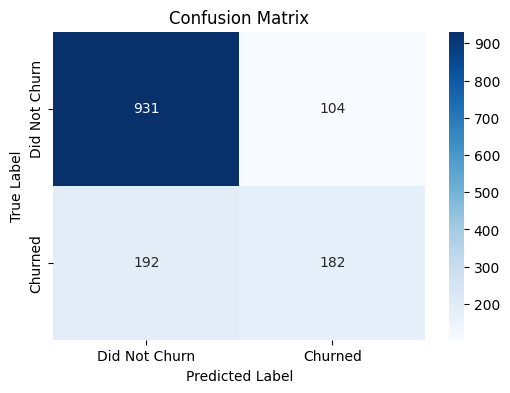

In [13]:
# Checking Predictions Below:

# Calculate the accuracy: (Number of correct predictions) / (Total number of predictions)
accuracy = accuracy_score(y_test, y_pred)
print(f"\nModel Accuracy on Test Set: {accuracy:.4f}") # Show accuracy with 4 decimal places

# Print a more detailed report showing precision, recall, f1 score for each class (Churn=0, Churn=1)
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Show the confusion matrix: correct vs. incorrect predictions
print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
print(cm)

# Let's make the confusion matrix easier to read with a plot
plt.figure(figsize=(6, 4)) # Set the size of the plot

# Use seaborn to create a heatmap
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', # Show numbers, use integer format, blue colors
            xticklabels=['Did Not Churn', 'Churned'], # Labels for columns
            yticklabels=['Did Not Churn', 'Churned']) # Labels for rows
plt.xlabel('Predicted Label') # Label for x-axis
plt.ylabel('True Label') # Label for y-axis
plt.title('Confusion Matrix') # Title for the plot
plt.show() # Display the plot
